In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PREFIX = "inertial-6286.188861:"

def read_csv(csv_path_file):
    buff = []
    with open(csv_path_file, "r") as file:
    # with open("CB_ARW.csv", "r") as file:
        data = False
        for line in file:
            
            if line == "DATA_START\n":
                data = True
                continue
            
            if data == True:
                line = line.rstrip()
                values = line.split(",")
                buff.append(values)

    header = [b.lstrip(PREFIX) for b in buff[0]]

    buff = np.array(buff)

    df = pd.DataFrame(data=buff[1:], columns=header)
    
    cols_to_drop = [c for c in df.columns if c.endswith('valid')]
    df = df.drop(columns=cols_to_drop)

    # Conversion de tipo de datos de df (string a numerico)
    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    return df

fs = 100
dt = 1 / fs


In [13]:
df_cuat = read_csv(r"pruebas_oficina_29-04\cuate_1.csv")

df_imu = read_csv(r"pruebas_oficina_29-04\imu_1.csv")

start_time_hhmmss = "16:19:20.26"

zupt_periods_hhmmss = [
    ("16:19:20.26", "16:19:38.00"),
    ("16:20:15.00", "16:20:35.00"),
    ("16:21:05.00", "16:21:33.67"),
]

In [14]:
# Renombrar columnas
cuat_new_names = ["q0", "q1", "q2", "q3"]
df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[1:], cuat_new_names)))

# Tiempo relativo en segundos
df_cuat["t"] = (df_cuat["Time"] - df_cuat["Time"].iloc[0]) / 1e9

# Delta de tiempo entre muestras
df_cuat["dt"] = df_cuat["t"].diff()

# Reordenar columnas
df_cuat = df_cuat.reindex(columns=['Time', 't', 'dt', 'q0', 'q1', 'q2', 'q3'])

df_cuat

,Time,t,dt,q0,q1,q2,q3
0,1777497560261134592,0.000000,NaN,1.000000,-0.000178,0.000025,0.000009
1,1777497560271331840,0.010197,0.010197,1.000000,-0.000178,0.000026,0.000005
2,1777497560281509632,0.020375,0.010178,1.000000,-0.000177,0.000031,-0.000004
3,1777497560291667456,0.030533,0.010158,1.000000,-0.000181,0.000033,-0.000014
4,1777497560301806080,0.040671,0.010139,1.000000,-0.000184,0.000034,-0.000021
...,...,...,...,...,...,...,...
13337,1777497693629504512,133.368370,0.009804,0.999918,-0.000960,-0.003820,-0.012179
13338,1777497693639289600,133.378155,0.009785,0.999918,-0.000961,-0.003818,-0.012183
13339,1777497693649523968,133.388389,0.010234,0.999918,-0.000963,-0.003817,-0.012186
13340,1777497693659739136,133.398605,0.010215,0.999918,-0.000965,-0.003813,-0.012187


In [15]:
al_new_names = ["alx", "aly", "alz"]

df_imu = df_imu.rename(columns=dict(zip(df_imu.columns[1:], al_new_names)))

df_imu

,Time,alx,aly,alz
0,1777497560269724928,-0.007542,0.030116,0.052630
1,1777497560279914496,-0.012045,0.026911,0.032203
2,1777497560290084096,-0.023940,0.008935,0.038940
3,1777497560300233728,-0.026809,-0.000188,0.040966
4,1777497560310364160,-0.032754,-0.000810,0.052100
...,...,...,...,...
13325,1777497693622398720,-0.018629,-0.022948,0.045157
13326,1777497693632197632,-0.018361,-0.024141,0.046555
13327,1777497693641977600,-0.011593,-0.020133,0.044552
13328,1777497693652206592,-0.005367,-0.014703,0.042454


In [16]:
tol_ns = 5_000_000  # 5 ms

df_u = pd.merge_asof(
    df_cuat,
    df_imu,
    on="Time",
    direction="nearest",
    tolerance=tol_ns
)

# Eliminar filas donde no hubo coincidencia dentro de la tolerancia
df_u = df_u.dropna(
    subset=["q0"]
).reset_index(drop=True)

df_u

,Time,t,dt,q0,q1,q2,q3,alx,aly,alz
0,1777497560261134592,0.000000,NaN,1.000000,-0.000178,0.000025,0.000009,NaN,NaN,NaN
1,1777497560271331840,0.010197,0.010197,1.000000,-0.000178,0.000026,0.000005,-0.007542,0.030116,0.052630
2,1777497560281509632,0.020375,0.010178,1.000000,-0.000177,0.000031,-0.000004,-0.012045,0.026911,0.032203
3,1777497560291667456,0.030533,0.010158,1.000000,-0.000181,0.000033,-0.000014,-0.023940,0.008935,0.038940
4,1777497560301806080,0.040671,0.010139,1.000000,-0.000184,0.000034,-0.000021,-0.026809,-0.000188,0.040966
...,...,...,...,...,...,...,...,...,...,...
13337,1777497693629504512,133.368370,0.009804,0.999918,-0.000960,-0.003820,-0.012179,-0.018361,-0.024141,0.046555
13338,1777497693639289600,133.378155,0.009785,0.999918,-0.000961,-0.003818,-0.012183,-0.011593,-0.020133,0.044552
13339,1777497693649523968,133.388389,0.010234,0.999918,-0.000963,-0.003817,-0.012186,-0.005367,-0.014703,0.042454
13340,1777497693659739136,133.398605,0.010215,0.999918,-0.000965,-0.003813,-0.012187,0.000894,-0.007598,0.041473


In [17]:
# Validación

print(df_u["dt"].describe())

fs_mean = 1 / df_u["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    13341.000000
mean         0.010000
std          0.000130
min          0.009770
25%          0.009889
50%          0.010002
75%          0.010110
max          0.010236
Name: dt, dtype: float64
Frecuencia promedio: 100.00 Hz


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def is_in_zupt_period(t, zupt_periods):
    """
    Verifica si el tiempo t está dentro de algún periodo ZUPT.

    zupt_periods:
        Lista de tuplas [(t_ini, t_fin), ...]
        Ejemplo:
            [(0, 5), (45, 55), (120, 130)]
    """
    if zupt_periods is None:
        return False

    for t_ini, t_fin in zupt_periods:
        if t_ini <= t <= t_fin:
            return True

    return False


def ins_strapdown_dead_reckoning(
    df,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    # Ganancias generales
    G_acc=1.0,
    p_gain=1.0,

    # ZUPT manual por tiempo
    zupt_periods=None,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    # Non-Holonomic Constraints
    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    # Convención de rotación
    use_transpose=True,

    # Opciones
    normalize_quat=True,
    verbose=True
):
    """
    INS strapdown básico para Dead Reckoning usando:
        - aceleración lineal en body
        - cuaternión de orientación
        - ZUPT manual por ventanas de tiempo
        - NHC para vehículo terrestre

    Parámetros
    ----------
    df : pd.DataFrame
        Debe contener columnas:
            Time, t, dt, q0, q1, q2, q3, alx, aly, alz

    acc_cols : tuple
        Columnas de aceleración lineal en body.

    quat_cols : tuple
        Columnas del cuaternión.
        Se asume:
            q0 = componente escalar w
            q1, q2, q3 = componentes vectoriales x, y, z

    time_col : str
        Columna de tiempo relativo en segundos.

    dt_col : str
        Columna de delta tiempo en segundos.

    zupt_periods : list of tuple
        Periodos donde se aplica ZUPT.
        Ejemplo:
            zupt_periods = [(0, 5), (45, 55), (100, 110)]

    ZUPT_GAIN : float
        Ganancia de corrección de velocidad.
        Si hard_zupt=True, la velocidad se fuerza a cero.
        Si hard_zupt=False, se aplica:
            v = v - ZUPT_GAIN * v

    hard_zupt : bool
        True  -> fuerza v = 0 durante ZUPT.
        False -> reduce velocidad suavemente según ZUPT_GAIN.

    use_nhc : bool
        Aplica restricciones no holonómicas.

    K_nhc_y : float
        Ganancia para reducir velocidad lateral en body.

    K_nhc_z : float
        Ganancia para reducir velocidad vertical en body.

    use_transpose : bool
        Si True:
            R_nb = r.as_matrix().T
        Si False:
            R_nb = r.as_matrix()

        Se deja como True porque coincide con tu script original.

    Retorna
    -------
    df_out : pd.DataFrame
        DataFrame con columnas agregadas:
            a_nav_x, a_nav_y, a_nav_z
            v_int_x, v_int_y, v_int_z
            vx_body_raw, vy_body_raw, vz_body_raw
            vx_body_nhc, vy_body_nhc, vz_body_nhc
            vx, vy, vz
            px, py, pz
            px_scale, py_scale, pz_scale
            zupt_flag
    """

    df_out = df.copy()

    # Inicialización
    p = np.zeros(3, dtype=float)
    v_prev = np.zeros(3, dtype=float)

    # Crear columnas de salida
    output_cols = [
        "a_nav_x", "a_nav_y", "a_nav_z",
        "a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc",
        "v_int_x", "v_int_y", "v_int_z",
        "vx_body_raw", "vy_body_raw", "vz_body_raw",
        "vx_body_nhc", "vy_body_nhc", "vz_body_nhc",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "px_scale", "py_scale", "pz_scale",
        "zupt_flag"
    ]

    for col in output_cols:
        df_out[col] = np.nan

    # Loop strapdown
    for k in range(len(df_out)):

        t = df_out.loc[k, time_col]
        dt = df_out.loc[k, dt_col]

        # Para la primera fila normalmente dt es NaN
        if pd.isna(t) or pd.isna(dt) or dt <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_flag"] = 0
            continue

        # -----------------------------
        # 1. Leer aceleración en body
        # -----------------------------
        a_body = df_out.loc[k, list(acc_cols)].to_numpy(dtype=float)

        # -----------------------------
        # 2. Leer y normalizar cuaternión
        # -----------------------------
        q = df_out.loc[k, list(quat_cols)].to_numpy(dtype=float)

        q_norm = np.linalg.norm(q)

        if normalize_quat:
            q = q / q_norm

        q0, q1, q2, q3 = q

        # scipy usa formato [x, y, z, w]
        r = R.from_quat([q1, q2, q3, q0])

        if use_transpose:
            R_nb = r.as_matrix().T
        else:
            R_nb = r.as_matrix()

        # -----------------------------
        # 3. Aceleración body -> navegación
        # -----------------------------
        a_nav = G_acc * (R_nb @ a_body)

        df_out.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

        # -----------------------------
        # 4. Integración de velocidad libre
        # -----------------------------
        v_free = v_prev + a_nav * dt

        df_out.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v_free

        # -----------------------------
        # 5. ZUPT manual po r periodos
        # -----------------------------
        zupt_flag = int(is_in_zupt_period(t, zupt_periods))
        df_out.loc[k, "zupt_flag"] = zupt_flag

        if zupt_flag == 1:
            if hard_zupt:
                v[:] = 0.0
            else:
                v = v - ZUPT_GAIN * v

        # -----------------------------
        # 6. NHC: velocidad nav -> body
        # -----------------------------
        if use_nhc:
            v_body = R_nb.T @ v

            df_out.loc[k, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

            # Restricción no holonómica:
            # vehículo no debería desplazarse lateral ni verticalmente
            # v_body[1] = v_body[1] * (1.0 - K_nhc_y)
            # v_body[2] = v_body[2] * (1.0 - K_nhc_z)
            K_nhc = np.array([1, 0, 0])
            v_body = v_body * K_nhc
            a_body_nhc = a_body * K_nhc
            df_out.loc[k, ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]] = a_body_nhc

            df_out.loc[k, ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]] = v_body

            # Volver a navegación
            v = R_nb @ v_body

            a_nav_nhc = R_nb @ a_body_nhc

        # -----------------------------
        # 7. Integración de posición
        # -----------------------------
        p = p + v * dt #+ (0.5 * a_nav_nhc * (dt**2))

        p_scale = p_gain * p

        df_out.loc[k, ["vx", "vy", "vz"]] = v
        df_out.loc[k, ["px", "py", "pz"]] = p
        df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale

    if verbose:
        print("INS strapdown finalizado.")
        print(f"Filas procesadas: {len(df_out)}")
        print(f"Posición final [m]: {p}")
        print(f"Velocidad final [m/s]: {v}")


    return df_out

In [19]:
import pandas as pd
import numpy as np

def hhmmss_to_seconds(hhmmss):
    """
    Convierte una hora tipo:
        '16:46:25.77'
        '16:47:00.7'
        '16:47:27'
    a segundos desde las 00:00:00.
    """

    parts = hhmmss.strip().split(":")

    if len(parts) != 3:
        raise ValueError(f"Formato inválido: {hhmmss}. Usa HH:MM:SS.sss")

    h = int(parts[0])
    m = int(parts[1])
    s = float(parts[2])

    return h * 3600 + m * 60 + s


def convert_zupt_periods_hhmmss_to_relative(zupt_periods_hhmmss, start_time_hhmmss):
    """
    Convierte periodos ZUPT dados en hora real HH:MM:SS.sss
    a periodos relativos en segundos respecto a start_time_hhmmss.

    Ejemplo:
        start_time_hhmmss = '16:46:09.77'

        zupt_periods_hhmmss = [
            ('16:46:25.77', '16:46:30.25'),
            ('16:46:52.64', '16:47:00.7')
        ]

    Retorna:
        [
            (16.0, 20.48),
            (42.87, 50.93)
        ]
    """

    t0_abs = hhmmss_to_seconds(start_time_hhmmss)

    zupt_periods_rel = []

    for t_ini_str, t_fin_str in zupt_periods_hhmmss:
        t_ini_abs = hhmmss_to_seconds(t_ini_str)
        t_fin_abs = hhmmss_to_seconds(t_fin_str)

        t_ini_rel = t_ini_abs - t0_abs
        t_fin_rel = t_fin_abs - t0_abs

        if t_fin_rel < t_ini_rel:
            raise ValueError(
                f"Periodo inválido: {t_ini_str} - {t_fin_str}. "
                "El tiempo final es menor que el inicial."
            )

        zupt_periods_rel.append((t_ini_rel, t_fin_rel))

    return zupt_periods_rel

In [20]:
zupt_periods = convert_zupt_periods_hhmmss_to_relative(
    zupt_periods_hhmmss,
    start_time_hhmmss
)

print(zupt_periods)

[(0.0, 17.739999999997963), (54.73999999999796, 74.73999999999796), (104.73999999999796, 133.40999999999622)]


In [21]:
# # Periodos donde sabes que el vehículo está detenido

# zupt_periods = [
#     #  t_inicio, t_final
#     (0, 18),    # detenido al inicio
#     (55, 75),
#     (105, 133),  # detenido al final
# ]

In [22]:
df_ins = ins_strapdown_dead_reckoning(
    df=df_u,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    G_acc=1.0,
    p_gain=1.0,

    zupt_periods=zupt_periods,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    use_transpose=True
)

df_ins.head()

INS strapdown finalizado.
Filas procesadas: 13342
Posición final [m]: [-0.63621315 -5.04996113 -0.324921  ]
Velocidad final [m/s]: [0. 0. 0.]


,Time,t,dt,q0,q1,q2,q3,alx,aly,alz,...,px,py,pz,px_scale,py_scale,pz_scale,zupt_flag,a_body_x_nhc,a_body_y_nhc,a_body_z_nhc
0,1777497560261134592,0.000000,NaN,1.0,-0.000178,0.000025,0.000009,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1777497560271331840,0.010197,0.010197,1.0,-0.000178,0.000026,0.000005,-0.007542,0.030116,0.052630,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.007542,0.0,0.0
2,1777497560281509632,0.020375,0.010178,1.0,-0.000177,0.000031,-0.000004,-0.012045,0.026911,0.032203,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.012045,0.0,0.0
3,1777497560291667456,0.030533,0.010158,1.0,-0.000181,0.000033,-0.000014,-0.023940,0.008935,0.038940,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.023940,0.0,0.0
4,1777497560301806080,0.040671,0.010139,1.0,-0.000184,0.000034,-0.000021,-0.026809,-0.000188,0.040966,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.026809,-0.0,0.0


In [23]:
df_ins.head

<bound method NDFrame.head of                       Time           t        dt        q0        q1  \
0      1777497560261134592    0.000000       NaN  1.000000 -0.000178   
1      1777497560271331840    0.010197  0.010197  1.000000 -0.000178   
2      1777497560281509632    0.020375  0.010178  1.000000 -0.000177   
3      1777497560291667456    0.030533  0.010158  1.000000 -0.000181   
4      1777497560301806080    0.040671  0.010139  1.000000 -0.000184   
...                    ...         ...       ...       ...       ...   
13337  1777497693629504512  133.368370  0.009804  0.999918 -0.000960   
13338  1777497693639289600  133.378155  0.009785  0.999918 -0.000961   
13339  1777497693649523968  133.388389  0.010234  0.999918 -0.000963   
13340  1777497693659739136  133.398605  0.010215  0.999918 -0.000965   
13341  1777497693669934336  133.408800  0.010195  0.999918 -0.000966   

             q2        q3       alx       aly       alz  ...        px  \
0      0.000025  0.000009      

In [24]:
# v_cols=("vx_body_raw", "vy_body_raw", "vz_body_raw")

# v_body = df_ins.loc[2000, list(v_cols)].to_numpy(dtype=float)

# # df_u.loc[2000, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

# print(v_body)
# print(v_body.shape)


# # Restricción no holonómica:
# # vehículo no debería desplazarse lateral ni verticalmente
# # v_body[1] = v_body[1] * (1.0 - K_nhc_y)
# # v_body[2] = v_body[2] * (1.0 - K_nhc_z)
# B = np.array([1, 0, 0])
# print(B)
# print(B.shape)
# v_body = v_body * B
# print(v_body)

In [25]:
df_ins

,Time,t,dt,q0,q1,q2,q3,alx,aly,alz,...,px,py,pz,px_scale,py_scale,pz_scale,zupt_flag,a_body_x_nhc,a_body_y_nhc,a_body_z_nhc
0,1777497560261134592,0.000000,NaN,1.000000,-0.000178,0.000025,0.000009,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN
1,1777497560271331840,0.010197,0.010197,1.000000,-0.000178,0.000026,0.000005,-0.007542,0.030116,0.052630,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,-0.007542,0.0,0.0
2,1777497560281509632,0.020375,0.010178,1.000000,-0.000177,0.000031,-0.000004,-0.012045,0.026911,0.032203,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,-0.012045,0.0,0.0
3,1777497560291667456,0.030533,0.010158,1.000000,-0.000181,0.000033,-0.000014,-0.023940,0.008935,0.038940,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,-0.023940,0.0,0.0
4,1777497560301806080,0.040671,0.010139,1.000000,-0.000184,0.000034,-0.000021,-0.026809,-0.000188,0.040966,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,-0.026809,-0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13337,1777497693629504512,133.368370,0.009804,0.999918,-0.000960,-0.003820,-0.012179,-0.018361,-0.024141,0.046555,...,-0.636213,-5.049961,-0.324921,-0.636213,-5.049961,-0.324921,1.0,-0.018361,-0.0,0.0
13338,1777497693639289600,133.378155,0.009785,0.999918,-0.000961,-0.003818,-0.012183,-0.011593,-0.020133,0.044552,...,-0.636213,-5.049961,-0.324921,-0.636213,-5.049961,-0.324921,1.0,-0.011593,-0.0,0.0
13339,1777497693649523968,133.388389,0.010234,0.999918,-0.000963,-0.003817,-0.012186,-0.005367,-0.014703,0.042454,...,-0.636213,-5.049961,-0.324921,-0.636213,-5.049961,-0.324921,1.0,-0.005367,-0.0,0.0
13340,1777497693659739136,133.398605,0.010215,0.999918,-0.000965,-0.003813,-0.012187,0.000894,-0.007598,0.041473,...,-0.636213,-5.049961,-0.324921,-0.636213,-5.049961,-0.324921,1.0,0.000894,-0.0,0.0


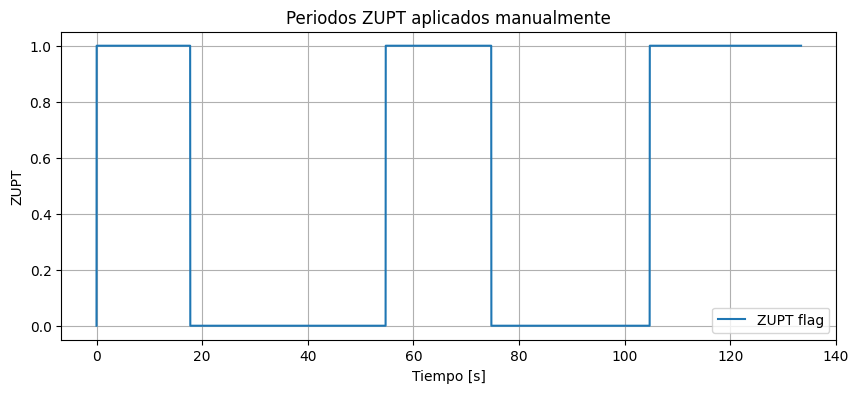

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(df_ins["t"], df_ins["zupt_flag"], label="ZUPT flag")
plt.xlabel("Tiempo [s]")
plt.ylabel("ZUPT")
plt.title("Periodos ZUPT aplicados manualmente")
plt.grid(True)
plt.legend()
plt.show()

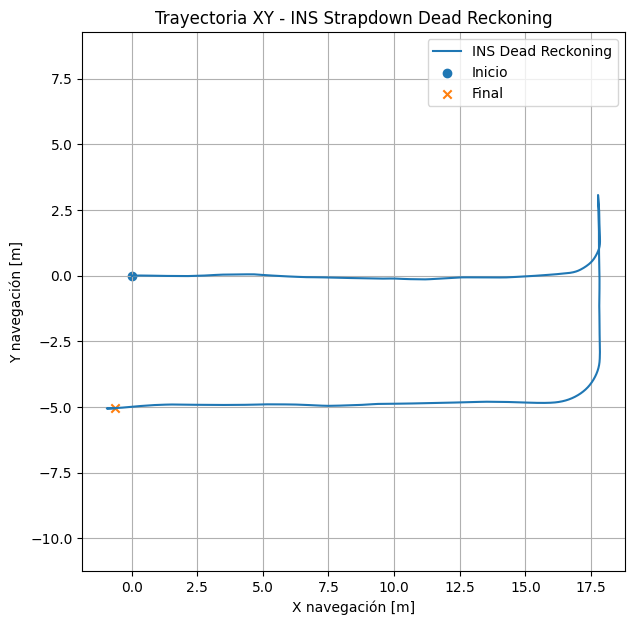

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_ins["px"], df_ins["py"], label="INS Dead Reckoning")

plt.scatter(df_ins["px"].iloc[0], df_ins["py"].iloc[0], label="Inicio", marker="o")
plt.scatter(df_ins["px"].iloc[-1], df_ins["py"].iloc[-1], label="Final", marker="x")

plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.title("Trayectoria XY - INS Strapdown Dead Reckoning")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

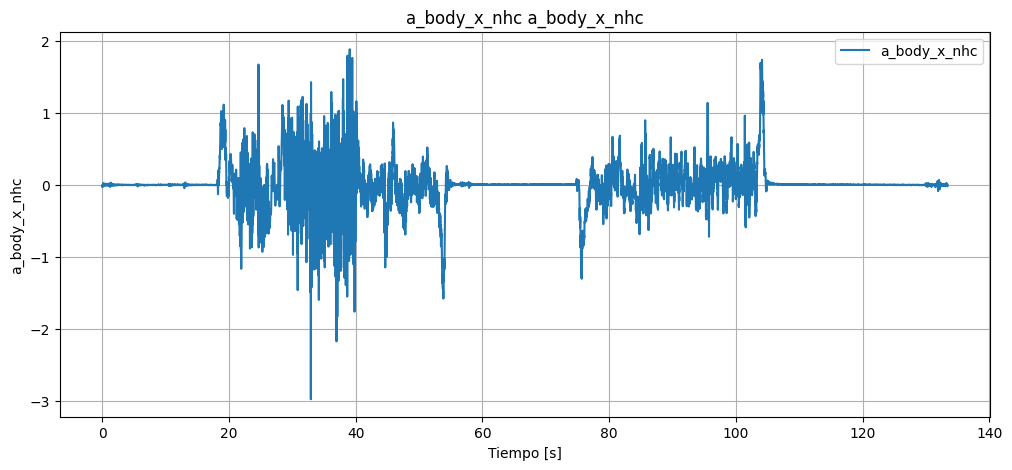

In [28]:
# for col in ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]:
col = "a_body_x_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("a_body_x_nhc")
plt.title(f"a_body_x_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()

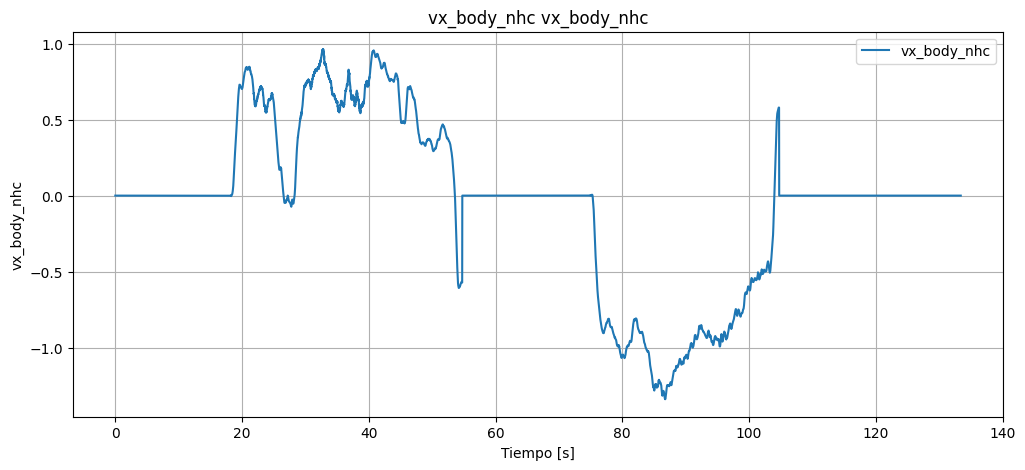

In [29]:
# for col in ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]:
col = "vx_body_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("vx_body_nhc")
plt.title(f"vx_body_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()


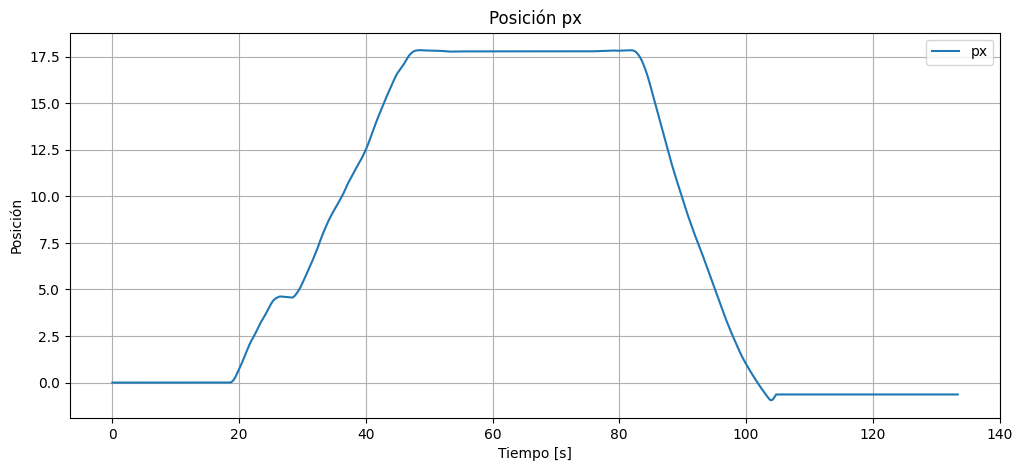

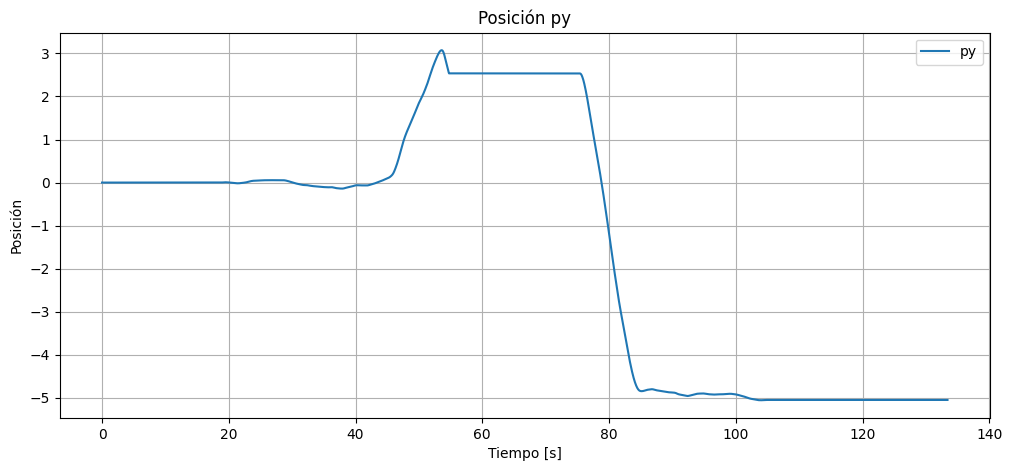

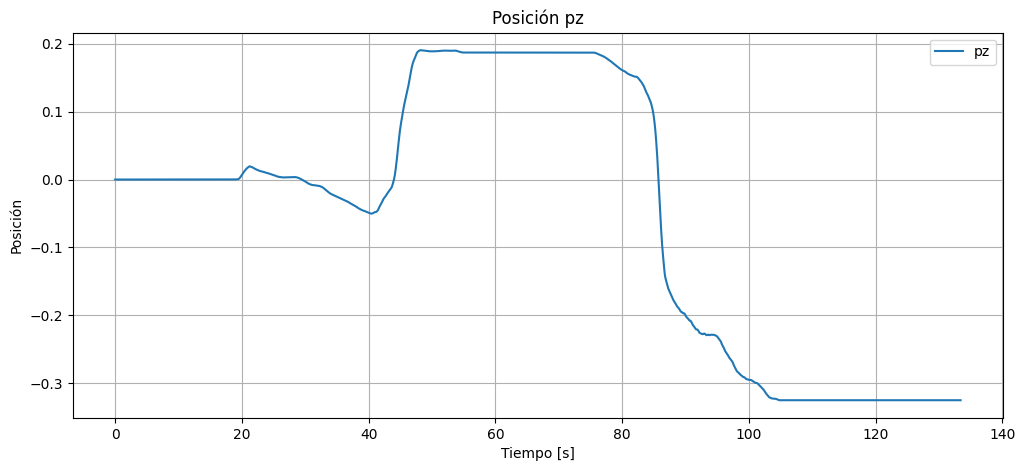

: 

In [ ]:
for col in ["px", "py", "pz"]:
    plt.figure(figsize=(12, 5))
    plt.plot(df_ins["t"], df_ins[col], label=col)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Posición")
    plt.title(f"Posición {col}")
    plt.legend()
    plt.grid(True)
    plt.show()